# CIFAR-10 AVG v3 — Custom Residual CNN + SVM Training

Use the official CIFAR-10 development split only. This notebook preserves the existing AVG grayscale preprocessing, fits a custom residual CNN and an individual SVM, and selects checkpoints and parameters using validation data. Official test scoring remains in `AVG Testing.ipynb`.


In [1]:
import os
import gc
import time
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 30092026
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
tf.random.set_seed(SEED)
tf.keras.mixed_precision.set_global_policy("mixed_float16")

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

print("GPU:", tf.config.list_physical_devices("GPU"))
print("Mixed precision:", tf.keras.mixed_precision.global_policy())

I0000 00:00:1791402657.509907   71413 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791402657.548133   71413 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791402658.595112   71413 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: <DTypePolicy "mixed_float16">


## 1. Load CIFAR-10

CIFAR-10 berisi 60.000 gambar RGB berukuran 32×32 pada 10 kelas.

Notebook training hanya mengambil **50.000 official training images**.
Official test split tidak digunakan di notebook ini.

Pada preprocessing, setiap gambar akan dikonversi menjadi **Grayscale AVG**:

```text
AVG = (R + G + B) / 3
```

In [2]:
# Di notebook training ini kita hanya mengambil official_train.
# Official test split dibuang dengan `_` dan tidak dipakai sama sekali.
(X_train_full, y_train_full), _ = cifar10.load_data()

labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

classes_name = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

print("Official CIFAR-10 RGB training images:", X_train_full.shape)
print("Official CIFAR-10 training labels    :", y_train_full.shape)

Official CIFAR-10 RGB training images: (50000, 32, 32, 3)
Official CIFAR-10 training labels    : (50000, 1)


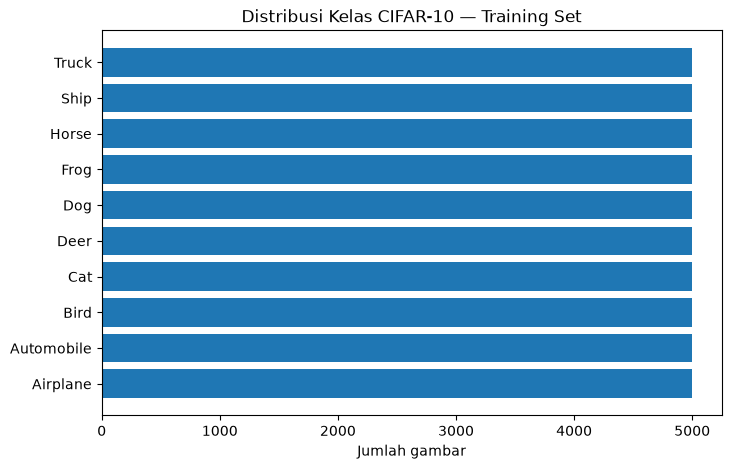

In [3]:
classes, counts = np.unique(y_train_full, return_counts=True)

plt.figure(figsize=(8, 5))
plt.barh(classes_name, counts)
plt.title("Distribusi Kelas CIFAR-10 — Training Set")
plt.xlabel("Jumlah gambar")
plt.show()

## 2. Tampilkan Contoh Gambar Grayscale AVG

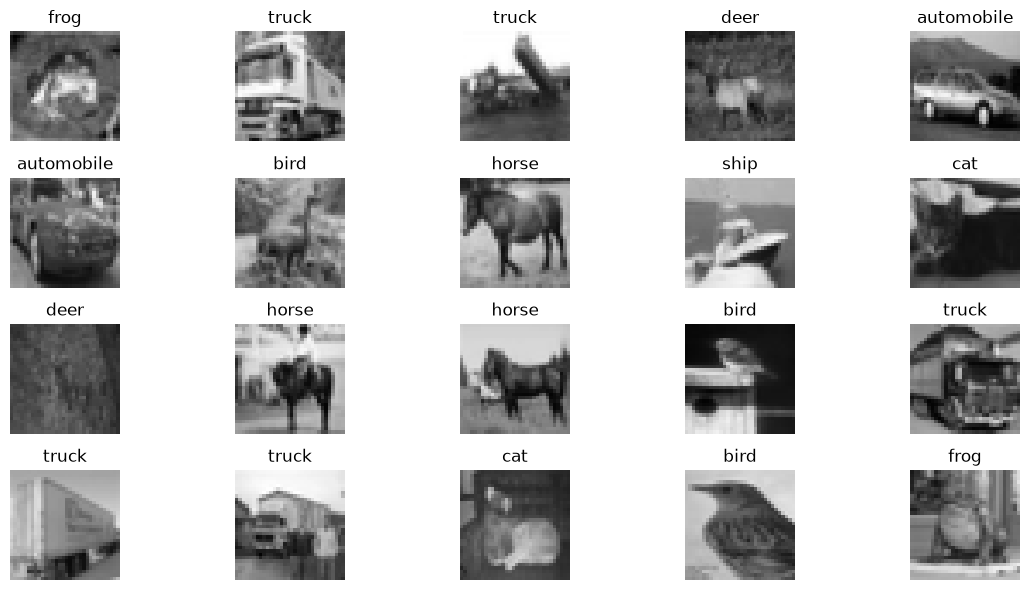

In [4]:
plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    avg_image = np.mean(
        X_train_full[i].astype("float32"),
        axis=-1
    )

    plt.imshow(
        avg_image,
        cmap="gray",
        vmin=0,
        vmax=255
    )
    plt.title(labels[int(y_train_full[i, 0])])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Preprocessing Grayscale AVG dan Train/Validation Split

Konversi yang digunakan:

```text
AVG = (R + G + B) / 3
```

Setelah konversi, setiap image memiliki shape:

```text
32 × 32 × 1
```

Kemudian nilai pixel dinormalisasi ke rentang `[0, 1]`.

`SEED = 30092026` dan stratified split dipertahankan agar sample order konsisten dengan eksperimen RGB.

In [5]:
# RGB -> Grayscale AVG -> normalisasi.
X_train_full = np.mean(
    X_train_full.astype("float32"),
    axis=-1,
    keepdims=True
) / 255.0

y_train_full = y_train_full.flatten()

# Validation diambil dari official training split.
# X_val/y_val TIDAK digunakan untuk gradient update.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

y_cat_train = to_categorical(y_train, 10)
y_cat_val = to_categorical(y_val, 10)

print("Training data   :", X_train.shape, y_train.shape)
print("Validation data :", X_val.shape, y_val.shape)
print()
print("Data yang benar-benar digunakan model.fit() untuk update bobot:")
print("X_train =", X_train.shape)
print("y_train =", y_train.shape)

assert X_train.shape == (40000, 32, 32, 1)
assert X_val.shape == (10000, 32, 32, 1)

Training data   : (40000, 32, 32, 1) (40000,)
Validation data : (10000, 32, 32, 1) (10000,)

Data yang benar-benar digunakan model.fit() untuk update bobot:
X_train = (40000, 32, 32, 1)
y_train = (40000,)


## 4. Custom residual CNN

Four residual stages (64, 128, 256, 512 channels) preserve spatial information before global average pooling. The 512-dimensional `svm_features` layer is **signed**: its output is batch-normalized without ReLU, avoiding dead embedding channels. All weights are trained from scratch.

In [6]:
INPUT_SHAPE = (32, 32, 1)
BATCH_SIZE = 128  # On 6 GB VRAM, restart from the top with 32 if this runs out of memory.
MAX_EPOCHS = 100
INITIAL_LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.30


def residual_block(x, filters, stride, name):
    shortcut = x
    x = Conv2D(filters, 3, strides=stride, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    x = BatchNormalization(name=f"{name}_bn1")(x)
    x = Activation("relu", name=f"{name}_relu1")(x)
    x = Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = BatchNormalization(name=f"{name}_bn2")(x)
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding="same", use_bias=False, name=f"{name}_shortcut_conv")(shortcut)
        shortcut = BatchNormalization(name=f"{name}_shortcut_bn")(shortcut)
    x = Add(name=f"{name}_add")([x, shortcut])
    return Activation("relu", name=f"{name}_out")(x)


def build_custom_cnn(
    initial_lr=INITIAL_LR,
    weight_decay=WEIGHT_DECAY,
    dropout_rate=DROPOUT_RATE,
    epochs=MAX_EPOCHS,
    training_samples=None,
    batch_size=BATCH_SIZE,
):
    inputs = Input(shape=INPUT_SHAPE, name="input_image")
    x = Conv2D(64, 3, padding="same", use_bias=False, name="stem_conv")(inputs)
    x = BatchNormalization(name="stem_bn")(x)
    x = Activation("relu", name="stem_relu")(x)
    for stage, filters in enumerate((64, 128, 256, 512), start=1):
        x = residual_block(x, filters, 1 if stage == 1 else 2, f"stage{stage}_block1")
        x = residual_block(x, filters, 1, f"stage{stage}_block2")
        
    feature_map = Activation("linear", name="feature_map")(x)
    pooled = GlobalAveragePooling2D(name="global_pool")(feature_map)
    projection = Dense(512, use_bias=False, name="embedding_dense")(pooled)
    embedding = BatchNormalization(name="svm_features", dtype="float32")(projection)
    head = Dropout(dropout_rate, seed=SEED, name="classifier_dropout")(embedding)
    
    outputs = Dense(10, activation="softmax", dtype="float32", name="cnn_softmax")(head)
    
    model = Model(inputs, outputs, name="custom_cifar10_avg_residual_v3")
    steps = int(np.ceil((len(X_train) if training_samples is None else training_samples) / batch_size)) * epochs
    schedule = tf.keras.optimizers.schedules.CosineDecay(initial_lr, decay_steps=steps, alpha=0.01)
    
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=schedule, weight_decay=weight_decay),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"],
    )
    return model

In [7]:
# The final model is constructed once in the training section.
print("Architecture: CIFAR residual CNN with a signed 512-D embedding")

Architecture: CIFAR residual CNN with a signed 512-D embedding


## 5. Training augmentation

Augmentation is applied only to training images. Validation and test images use normalized pixels without random transforms.

In [8]:
data_generator = ImageDataGenerator(
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.10,
    fill_mode="reflect",
)

## 6. GridSearchCV for custom CNN settings

GridSearchCV evaluates four custom residual CNN configurations using a stratified 15,000-image subset of the 40,000 training rows.

The held-out 10,000 validation rows are used only to score each candidate through an RBF-SVM probe trained on the CNN embedding. They are not used for CNN gradient updates.

Search parameters:
- `initial_lr`: 0.001 and 0.0003
- `dropout_rate`: 0.30 and 0.50
- `weight_decay`: fixed at 0.0001
- maximum search epochs: 30
- batch size: 128

After selection, the winning configuration is trained again from scratch using all 40,000 training rows for up to 100 epochs.

In [9]:
print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)

Training rows: 40000
Validation rows: 10000
Batch size: 128
Maximum epochs: 100


### CNN search configuration and sklearn-compatible estimator

This cell defines the reduced hyperparameter space and the custom estimator used by `GridSearchCV`. Weight decay is fixed so the search remains computationally manageable.

In [10]:
CNN_GRID = {
    "initial_lr": (1e-3, 3e-4),
    "dropout_rate": (0.30, 0.50),
}

SEARCH_EPOCHS = 30
CNN_SEARCH_SAMPLES = 15000

# weight_decay is intentionally fixed, not searched.
SEARCH_WEIGHT_DECAY = WEIGHT_DECAY
CNN_MODEL_PATH = "models/cifar10_avg_cnn_v3.keras"

class CNNEmbeddingSearchEstimator(
    ClassifierMixin,
    BaseEstimator,
):
    def __init__(
        self,
        initial_lr=INITIAL_LR,
        dropout_rate=DROPOUT_RATE,
        weight_decay=SEARCH_WEIGHT_DECAY,
        search_epochs=SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
    ):
        self.initial_lr = initial_lr
        self.dropout_rate = dropout_rate
        self.weight_decay = weight_decay
        self.search_epochs = search_epochs
        self.batch_size = batch_size

    def fit(self, X, y):
        # Release the previous Keras graph before creating another candidate.
        tf.keras.backend.clear_session()
        gc.collect()

        tf.random.set_seed(SEED)
        np.random.seed(SEED)
        random.seed(SEED)

        self.classes_ = np.unique(y)

        self.cnn_model_ = build_custom_cnn(
            initial_lr=self.initial_lr,
            weight_decay=self.weight_decay,
            dropout_rate=self.dropout_rate,
            epochs=self.search_epochs,
            training_samples=len(X),
            batch_size=self.batch_size,
        )

        generator = data_generator.flow(
            X,
            to_categorical(y, 10),
            batch_size=self.batch_size,
            shuffle=True,
            seed=SEED,
        )

        # verbose=1 gives visible progress for every epoch.
        self.cnn_model_.fit(
            generator,
            epochs=self.search_epochs,
            verbose=1,
        )

        self.extractor_ = Model(
            self.cnn_model_.input,
            self.cnn_model_.get_layer(
                "svm_features"
            ).output,
        )

        train_features = self.extractor_.predict(
            X,
            batch_size=128,
            verbose=1,
        ).astype(np.float32)

        assert np.isfinite(
            train_features
        ).all()

        self.probe_ = Pipeline(
            [
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "svm",
                    SVC(
                        kernel="rbf",
                        C=10,
                        gamma="scale",
                        cache_size=2048,
                    ),
                ),
            ]
        )

        self.probe_.fit(
            train_features,
            y,
        )

        return self

    def predict(self, X):
        features = self.extractor_.predict(
            X,
            batch_size=128,
            verbose=0,
        ).astype(np.float32)

        return self.probe_.predict(
            features
        )

    def score(self, X, y):
        return accuracy_score(
            y,
            self.predict(X),
        )


CNN_GRID_CANDIDATES = (
    len(CNN_GRID["initial_lr"])
    * len(CNN_GRID["dropout_rate"])
)

print(
    "CNN GridSearchCV candidates:",
    CNN_GRID_CANDIDATES,
)
print(
    "CNN search training samples:",
    CNN_SEARCH_SAMPLES,
)
print(
    "Search epochs per candidate:",
    SEARCH_EPOCHS,
)
print(
    "Search/final batch size:",
    BATCH_SIZE,
)
print(
    "Fixed weight decay:",
    SEARCH_WEIGHT_DECAY,
)
print(
    "Final training maximum epochs:",
    MAX_EPOCHS,
)

CNN GridSearchCV candidates: 4
CNN search training samples: 15000
Search epochs per candidate: 30
Search/final batch size: 128
Fixed weight decay: 0.0001
Final training maximum epochs: 100


## 7. Train AVG CNN and save the best validation checkpoint

In [11]:
# ================================================================
# 1. Build a deterministic stratified 15K subset from X_train only
# ================================================================

all_train_indices = np.arange(len(X_train))

cnn_search_indices, _ = train_test_split(
    all_train_indices,
    train_size=CNN_SEARCH_SAMPLES,
    random_state=SEED,
    stratify=y_train,
)

X_cnn_search_train = X_train[cnn_search_indices]
y_cnn_search_train = y_train[cnn_search_indices]

print("CNN search training data :", X_cnn_search_train.shape)
print("CNN search validation    :", X_val.shape)

assert len(X_cnn_search_train) == CNN_SEARCH_SAMPLES


# ================================================================
# 2. Prepare a fixed train/validation split for GridSearchCV
#
# -1 = training rows
#  0 = validation rows
#
# Validation data is NEVER used for CNN gradient updates.
# ================================================================

X_cnn_search = np.concatenate(
    (
        X_cnn_search_train,
        X_val,
    ),
    axis=0,
)

y_cnn_search = np.concatenate(
    (
        y_cnn_search_train,
        y_val,
    ),
    axis=0,
)

cnn_validation_split = PredefinedSplit(
    test_fold=np.concatenate(
        (
            np.full(
                len(y_cnn_search_train),
                -1,
                dtype=int,
            ),
            np.zeros(
                len(y_val),
                dtype=int,
            ),
        )
    )
)

print("\nGridSearchCV input:")
print("Total rows :", X_cnn_search.shape[0])
print(
    "Train rows:",
    np.sum(cnn_validation_split.test_fold == -1),
)
print(
    "Val rows  :",
    np.sum(cnn_validation_split.test_fold == 0),
)


# ================================================================
# 3. Run CNN GridSearchCV
# ================================================================

cnn_search = GridSearchCV(
    estimator=CNNEmbeddingSearchEstimator(
        weight_decay=SEARCH_WEIGHT_DECAY,
        search_epochs=SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
    ),
    param_grid=CNN_GRID,
    cv=cnn_validation_split,
    scoring=None,
    refit=False,
    n_jobs=1,
    error_score="raise",
    verbose=2,
)

cnn_search.fit(
    X_cnn_search,
    y_cnn_search,
)


# ================================================================
# 4. Read and display GridSearchCV results
# ================================================================

best_cnn_config = cnn_search.best_params_.copy()

# weight_decay is fixed rather than searched,
# so add it manually to the winning configuration.
best_cnn_config["weight_decay"] = SEARCH_WEIGHT_DECAY

best_probe_accuracy = float(
    cnn_search.best_score_
)

grid_results = pd.DataFrame(
    [
        {
            **params,
            "weight_decay": SEARCH_WEIGHT_DECAY,
            "svm_probe_val_accuracy": float(score),
        }
        for params, score in zip(
            cnn_search.cv_results_["params"],
            cnn_search.cv_results_["mean_test_score"],
        )
    ]
).sort_values(
    "svm_probe_val_accuracy",
    ascending=False,
).reset_index(drop=True)

display(grid_results)

print("\nSelected CNN configuration:")
print(best_cnn_config)

print(
    "\nBest SVM-probe validation accuracy:",
    f"{best_probe_accuracy:.4%}",
)


# ================================================================
# 5. Clean GridSearch objects before final CNN training
# ================================================================

del cnn_search
del X_cnn_search
del y_cnn_search
del X_cnn_search_train
del y_cnn_search_train

tf.keras.backend.clear_session()
gc.collect()

print("\nGridSearch objects cleared from memory.")


# ================================================================
# 6. Reset random seeds before final CNN training
# ================================================================

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

CNN search training data : (15000, 32, 32, 1)
CNN search validation    : (10000, 32, 32, 1)

GridSearchCV input:
Total rows : 25000
Train rows: 15000
Val rows  : 10000
Fitting 1 folds for each of 4 candidates, totalling 4 fits


I0000 00:00:1791402661.930007   71413 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3672 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/30


I0000 00:00:1791402662.834809   71413 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1791402668.892235   71479 service.cc:153] XLA service 0x7e3cf403b9a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791402668.892257   71479 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1791402669.088989   71479 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791402670.454813   71479 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1791402670.640870   71479 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16608__.144
I0000 00:00:1791402677.696851   71576 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusio

  1/118 ━━━━━━━━━━━━━━━━━━━━ 46:11 24s/step - accuracy: 0.1172 - loss: 3.5555

...

 53/118 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.2266 - loss: 2.5828

I0000 00:00:1791403878.807773   71479 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_119838__.144


118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 149ms/step - accuracy: 0.2845 - loss: 2.3357
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.4005 - loss: 1.9436
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.4639 - loss: 1.8099
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.5057 - loss: 1.6710
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.5598 - loss: 1.5347
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.5831 - loss: 1.4512
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.6205 - loss: 1.3505
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.6195 - loss: 1.3798
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.6285 - loss: 1.3050
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.6602 - loss: 1.2199
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.6857 - loss: 1.1272
Epoch 12/30
118/118 ━━━━━━━━━━━━━━━━━━━━

,dropout_rate,initial_lr,weight_decay,svm_probe_val_accuracy
0,0.3,0.0010,0.0001,0.8398
1,0.3,0.0003,0.0001,0.8186
2,0.5,0.0003,0.0001,0.8124
3,0.5,0.0010,0.0001,0.8082



Selected CNN configuration:
{'dropout_rate': 0.3, 'initial_lr': 0.001, 'weight_decay': 0.0001}

Best SVM-probe validation accuracy: 83.9800%

GridSearch objects cleared from memory.


In [12]:
# ================================================================
# 7. Build the final CNN using the winning configuration
#
# Final CNN is trained FROM SCRATCH using all 40K training rows.
# ================================================================

model = build_custom_cnn(
    **best_cnn_config,
    epochs=MAX_EPOCHS,
    training_samples=len(X_train),
    batch_size=BATCH_SIZE,
)

print("\nFinal CNN configuration:")
print("Training samples :", len(X_train))
print("Validation       :", len(X_val))
print("Batch size       :", BATCH_SIZE)
print("Maximum epochs   :", MAX_EPOCHS)
print("Parameters       :", best_cnn_config)


# ================================================================
# 8. Create augmented training generator
# ================================================================

train_generator = data_generator.flow(
    X_train,
    y_cat_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)


# ================================================================
# 9. Final-training callbacks
#
# ModelCheckpoint saves the CNN with the highest validation accuracy.
#
# EarlyStopping prevents unnecessary training after validation
# accuracy stops improving.
#
# Learning rate is already controlled by CosineDecay inside
# build_custom_cnn(), so ReduceLROnPlateau is intentionally not used.
# ================================================================

callbacks = [
    ModelCheckpoint(
        CNN_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),

]


# ================================================================
# 10. Train final CNN
# ================================================================

started = time.time()

history = model.fit(
    train_generator,
    epochs=MAX_EPOCHS,
    validation_data=(
        X_val,
        y_cat_val,
    ),
    callbacks=callbacks,
    verbose=1,
)

final_training_seconds = time.time() - started


# ================================================================
# 11. Summarize final CNN training
# ================================================================

best_epoch = int(
    np.argmax(
        history.history["val_accuracy"]
    ) + 1
)

best_val_accuracy = float(
    np.max(
        history.history["val_accuracy"]
    )
)

print("\n" + "=" * 80)
print("FINAL CNN TRAINING SUMMARY")
print("=" * 80)

print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation accuracy:",
    f"{best_val_accuracy:.4%}",
)

print(
    "Training time:",
    f"{final_training_seconds:.1f} seconds",
)

print(
    "Best CNN saved to:",
    CNN_MODEL_PATH,
)


Final CNN configuration:
Training samples : 40000
Validation       : 10000
Batch size       : 128
Maximum epochs   : 100
Parameters       : {'dropout_rate': 0.3, 'initial_lr': 0.001, 'weight_decay': 0.0001}
Epoch 1/100


I0000 00:00:1791404261.810072   71484 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_154248__.144


105/313 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.2756 - loss: 2.2012

I0000 00:00:1791404278.554170   71484 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_154248__.144
I0000 00:00:1791404280.122810   79523 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 4 bytes spill stores, 4 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.3732 - loss: 1.9364
Epoch 1: val_accuracy improved from None to 0.16580, saving model to models/cifar10_avg_cnn_v3.keras

Epoch 1: finished saving model to models/cifar10_avg_cnn_v3.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 174ms/step - accuracy: 0.3732 - loss: 1.9364 - val_accuracy: 0.1658 - val_loss: 2.5620
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5104 - loss: 1.6024
Epoch 2: val_accuracy improved from 0.16580 to 0.30660, saving model to models/cifar10_avg_cnn_v3.keras

Epoch 2: finished saving model to models/cifar10_avg_cnn_v3.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.5104 - loss: 1.6024 - val_accuracy: 0.3066 - val_loss: 3.1877
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5943 - loss: 1.3733
Epoch 3: val_accuracy improved from 0.30660 to 0.55250, saving model to models/cifar10_avg_cnn_v3.keras

Epoch 3: finished saving model to models/cifar10_avg_cnn_v3.k

## 8. Training Curve

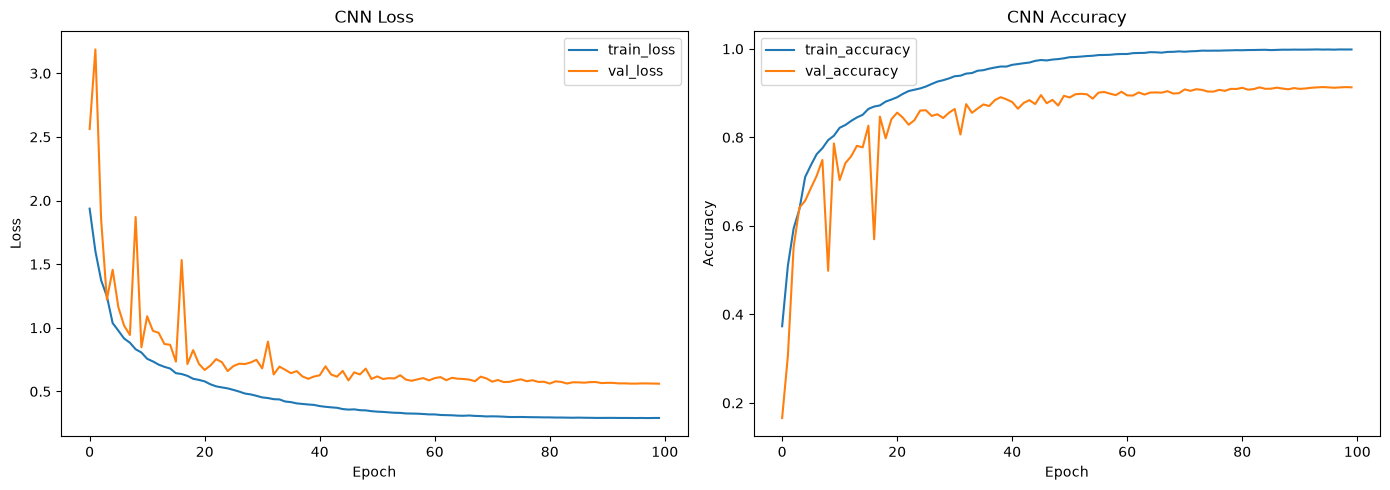

Best epoch: 95
Best validation accuracy during training: 91.37%


In [13]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

best_epoch = int(history_df["val_accuracy"].idxmax() + 1)
best_val_history = float(history_df["val_accuracy"].max())

print("Best epoch:", best_epoch)
print(
    f"Best validation accuracy during training: "
    f"{best_val_history * 100:.2f}%"
)

## 9. Load CNN Grayscale AVG Terbaik

Seluruh proses feature extraction berikutnya menggunakan checkpoint CNN AVG dengan validation accuracy terbaik.

In [14]:
best_cnn = load_model(
    CNN_MODEL_PATH
)

cnn_val_loss, cnn_val_accuracy = best_cnn.evaluate(
    X_val,
    y_cat_val,
    verbose=1
)

print(f"CNN validation loss    : {cnn_val_loss:.4f}")
print(
    f"CNN validation accuracy: "
    f"{cnn_val_accuracy * 100:.2f}%"
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9137 - loss: 0.5615
CNN validation loss    : 0.5615
CNN validation accuracy: 91.37%


## 10. Visualize selected CNN feature maps on a validation image

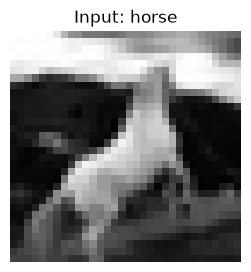

stem_relu: (1, 32, 32, 64)


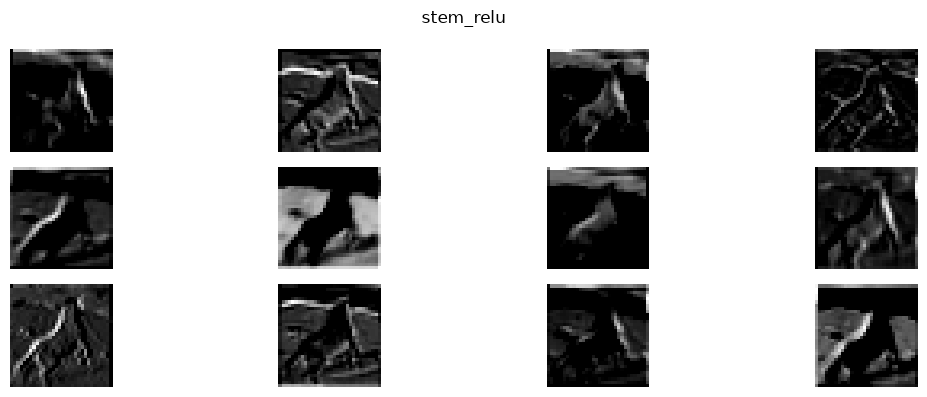

stage2_block2_out: (1, 16, 16, 128)


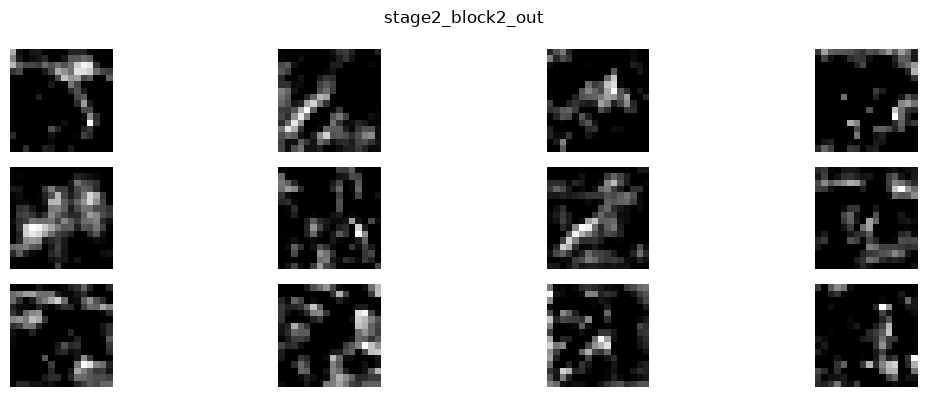

stage3_block2_out: (1, 8, 8, 256)


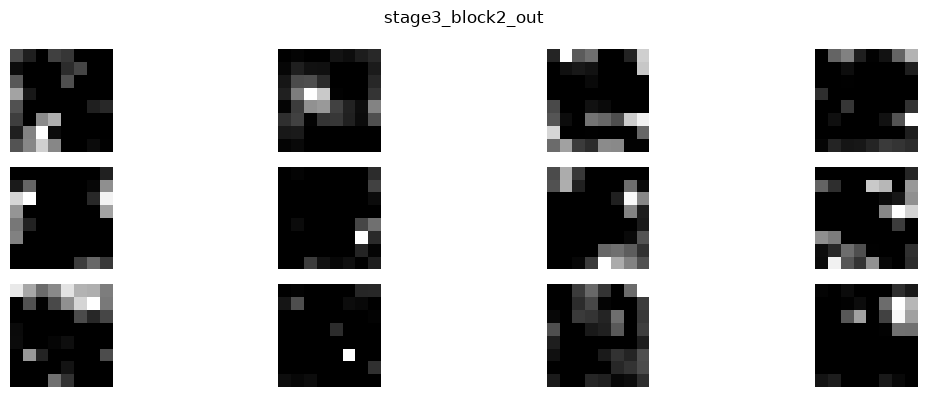

feature_map: (1, 4, 4, 512)


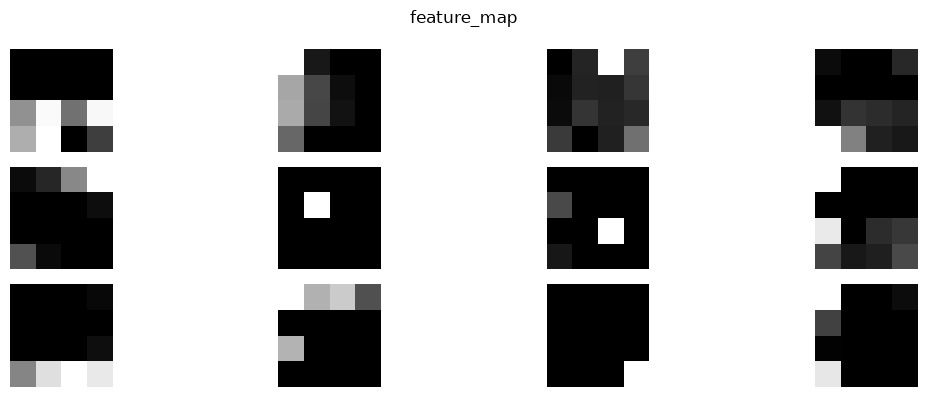

In [25]:
FEATURE_MAP_LAYERS = ["stem_relu", "stage2_block2_out", "stage3_block2_out", "feature_map"]
feature_map_model = Model(best_cnn.input, [best_cnn.get_layer(name).output for name in FEATURE_MAP_LAYERS])

sample_index = 0
sample_image = X_val[sample_index:sample_index + 1]
feature_maps = feature_map_model.predict(sample_image, verbose=0)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0, :, :, 0], cmap="gray")
plt.title(f"Input: {labels[y_val[sample_index]]}")
plt.axis("off")
plt.show()

for layer_name, fmap in zip(FEATURE_MAP_LAYERS, feature_maps):
    n_show = min(12, fmap.shape[-1])
    print(f"{layer_name}: {fmap.shape}")
    plt.figure(figsize=(12, 4))
    for i in range(n_show):
        plt.subplot(3, 4, i + 1)
        plt.imshow(fmap[0, :, :, i], cmap="grey")
        plt.axis("off")
    plt.suptitle(layer_name)
    plt.tight_layout()
    plt.show()

## 11. Extract signed AVG embeddings for the individual SVM

Use the named `svm_features` layer (512 values) from the best validation checkpoint. These features are also extracted for all splits by `AVG Extraction.ipynb`.

In [26]:
feature_extractor = Model(
    inputs=best_cnn.input,
    outputs=best_cnn.get_layer(
        "svm_features"
    ).output,
    name="cnn_feature_extractor"
)

feature_extractor.summary()

Model: "cnn_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        576 │ input_image[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 32, 32,    │     36,864 │ stem_relu[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_out   │ (None, 32, 32,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 32, 32,    │     36,864 │ stage1_block1_ou… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 32, 32,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_add   │ (None, 32, 32,    │          0 │ stage1_block2_bn

 Total params: 11,441,472 (43.65 MB)

 Trainable params: 11,430,848 (43.61 MB)

 Non-trainable params: 10,624 (41.50 KB)

In [27]:
X_train_features = feature_extractor.predict(X_train, batch_size=128, verbose=1).astype(np.float32)
X_val_features = feature_extractor.predict(X_val, batch_size=128, verbose=1).astype(np.float32)

assert X_train_features.shape == (40000, 512)
assert X_val_features.shape == (10000, 512)
assert np.isfinite(X_train_features).all() and np.isfinite(X_val_features).all()

print("Train/validation features:", X_train_features.shape, X_val_features.shape)
print("Constant training channels:", int((np.ptp(X_train_features, axis=0) == 0).sum()))

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
Train/validation features: (40000, 512) (10000, 512)
Constant training channels: 0


## 12. Select the individual AVG SVM with GridSearchCV

The CNN was fitted on the 40,000 training images. Ordinary K-fold CV on those embeddings would be optimistic. `PredefinedSplit` makes `GridSearchCV` fit each SVM on only those 40,000 embeddings and score it on the untouched 10,000 validation embeddings. `refit=False` prevents an automatic fit on validation labels.


In [28]:
SVM_C_VALUES = (1, 10, 30)
SVM_GAMMA_VALUES = ('scale', 0.001)

X_svm_search = np.concatenate((X_train_features, X_val_features), axis=0)
y_svm_search = np.concatenate((y_train, y_val), axis=0)
validation_split = PredefinedSplit(
    test_fold=np.concatenate((
        np.full(len(y_train), -1, dtype=int),
        np.zeros(len(y_val), dtype=int),
    ))
)
svm_search = GridSearchCV(
    estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', cache_size=2048)),
    ]),
    param_grid={'svm__C': SVM_C_VALUES, 'svm__gamma': SVM_GAMMA_VALUES},
    cv=validation_split,
    scoring='accuracy',
    refit=False,
    n_jobs=1,
    error_score='raise',
)
svm_search.fit(X_svm_search, y_svm_search)
best_svm_val_accuracy = float(svm_search.best_score_)
best_svm_params = (
    svm_search.best_params_['svm__C'],
    svm_search.best_params_['svm__gamma'],
)
svm_results = [
    {'C': params['svm__C'], 'gamma': params['svm__gamma'],
     'validation_accuracy': float(score)}
    for params, score in zip(
        svm_search.cv_results_['params'], svm_search.cv_results_['mean_test_score']
    )
]
print('Selected parameters:', best_svm_params)


Selected parameters: (1, 'scale')


In [29]:
display(pd.DataFrame(svm_results).sort_values("validation_accuracy", ascending=False))

,C,gamma,validation_accuracy
0,1,scale,0.9147
1,1,0.001,0.9147
5,30,0.001,0.9146
2,10,scale,0.9143
4,30,scale,0.9143
3,10,0.001,0.9142


In [30]:
# Model selection uses validation scores, never official test accuracy.
print(f"Best individual AVG SVM validation accuracy: {best_svm_val_accuracy:.4%}")

Best individual AVG SVM validation accuracy: 91.4700%


## 13. Fit the selected AVG SVM on the 40,000 CNN training embeddings

In [31]:
best_C, best_gamma = best_svm_params
final_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=best_C, gamma=best_gamma, cache_size=2048)),
])
final_svm.fit(X_train_features, y_train)
print("Final individual AVG SVM:", best_C, best_gamma)

Final individual AVG SVM: 1 scale


## 14. Validation — CNN Softmax vs CNN Feature Extraction + SVM

In [32]:
cnn_val_probability = best_cnn.predict(X_val, batch_size=128, verbose=1)
cnn_val_prediction = np.argmax(cnn_val_probability, axis=1)
cnn_val_acc = accuracy_score(y_val, cnn_val_prediction)

svm_val_prediction = final_svm.predict(X_val_features)
svm_val_acc = accuracy_score(y_val, svm_val_prediction)

display(pd.DataFrame({
    "Model": ["Custom CNN + Softmax", "Custom CNN Features + RBF-SVM"],
    "Validation Accuracy": [cnn_val_acc, svm_val_acc],
}))

print(f"CNN validation accuracy: {cnn_val_acc:.4%}")
print(f"SVM validation accuracy: {svm_val_acc:.4%}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


,Model,Validation Accuracy
0,Custom CNN + Softmax,0.9137
1,Custom CNN Features + RBF-SVM,0.9147


CNN validation accuracy: 91.3700%
SVM validation accuracy: 91.4700%


In [33]:
print(
    classification_report(
        y_val,
        svm_val_prediction,
        target_names=labels,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.9257    0.9470    0.9362      1000
  automobile     0.9658    0.9610    0.9634      1000
        bird     0.8775    0.8880    0.8827      1000
         cat     0.8234    0.8020    0.8126      1000
        deer     0.9061    0.8970    0.9015      1000
         dog     0.8603    0.8560    0.8581      1000
        frog     0.9269    0.9380    0.9324      1000
       horse     0.9357    0.9310    0.9333      1000
        ship     0.9680    0.9680    0.9680      1000
       truck     0.9552    0.9590    0.9571      1000

    accuracy                         0.9147     10000
   macro avg     0.9145    0.9147    0.9145     10000
weighted avg     0.9145    0.9147    0.9145     10000



## 15. Save the two AVG v3 models

`cifar10_avg_cnn_v3.keras` is the best validation checkpoint. `cifar10_avg_svm_v3.joblib` stores the fitted individual StandardScaler + RBF-SVM. Neither is a test result.

In [34]:
SVM_MODEL_PATH = "models/cifar10_avg_svm_v3.joblib"
joblib.dump(final_svm, SVM_MODEL_PATH)
print("Saved CNN:", CNN_MODEL_PATH)
print("Saved SVM:", SVM_MODEL_PATH)

Saved CNN: models/cifar10_avg_cnn_v3.keras
Saved SVM: models/cifar10_avg_svm_v3.joblib


# AVG v3 training complete

Next run `AVG Extraction.ipynb` and rebuild `combined_features_v3.npz`. Defer `AVG Testing.ipynb` until the fusion configuration is fixed and the final SVM artifact is saved.
